In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)

# ---- Configuration ----
n_rows = 1200   # Number of transactions

# Realistic Ghana locations
branches = ['Accra Central', 'Takoradi', 'Kumasi', 'Cape Coast', 'Tema', 'Tarkwa']
regions = {
    'Accra Central': 'Greater Accra',
    'Tema': 'Greater Accra',
    'Takoradi': 'Western',
    'Tarkwa': 'Western',
    'Kumasi': 'Ashanti',
    'Cape Coast': 'Central'
}

# Footwear categories and sample products
categories = {
    'Men\'s Shoes': ['Classic Oxford', 'Casual Loafer', 'Leather Boot', 'Sports Sneaker'],
    'Women\'s Shoes': ['Heeled Pump', 'Flat Sandal', 'Ankle Boot', 'Ballet Flat'],
    'Children\'s Shoes': ['School Shoe', 'Kids Sneaker', 'Canvas Shoe'],
    'Sandals': ['Men\'s Sandal', 'Ladies Slipper', 'Children\'s Sandal'],
    'Sports Shoes': ['Running Shoe', 'Training Shoe', 'Football Boot']
}

colours = ['Black', 'Brown', 'White', 'Navy', 'Grey', 'Tan', 'Red']
sizes = [36, 37, 38, 39, 40, 41, 42, 43, 44, 45]
payment_methods = ['Cash', 'Mobile Money', 'Card', 'Credit']
customer_types = ['Retail', 'Wholesale']
stock_movements = ['Sale', 'Restock', 'Return', 'Adjustment']

# Generate dates (last 18 months)
start_date = datetime(2024, 1, 1)
dates = [start_date + timedelta(days=np.random.randint(0, 550)) for _ in range(n_rows)]

# Build the dataset
data = []

for i in range(n_rows):
    branch = np.random.choice(branches)
    region = regions[branch]
    category = np.random.choice(list(categories.keys()))
    product = np.random.choice(categories[category])
    size = np.random.choice(sizes)
    colour = np.random.choice(colours)

    # Realistic pricing in GHS
    if category == 'Men\'s Shoes':
        unit_price = round(np.random.uniform(180, 450), 2)
    elif category == 'Women\'s Shoes':
        unit_price = round(np.random.uniform(150, 380), 2)
    elif category == 'Sports Shoes':
        unit_price = round(np.random.uniform(200, 500), 2)
    elif category == 'Sandals':
        unit_price = round(np.random.uniform(60, 180), 2)
    else:  # Children's
        unit_price = round(np.random.uniform(80, 220), 2)

    qty_sold = np.random.randint(1, 8)
    total_sales = round(qty_sold * unit_price, 2)

    # Stock after transaction (realistic range)
    qty_in_stock = np.random.randint(5, 85)

    movement = np.random.choice(stock_movements, p=[0.75, 0.12, 0.08, 0.05])  # Mostly sales

    data.append({
        'Date': dates[i].strftime('%Y-%m-%d'),
        'Branch': branch,
        'Region': region,
        'Product_Category': category,
        'Product_Name': product,
        'Size': size,
        'Colour': colour,
        'Quantity_Sold': qty_sold if movement == 'Sale' else 0,
        'Unit_Price_GHS': unit_price,
        'Total_Sales_GHS': total_sales if movement == 'Sale' else 0,
        'Quantity_In_Stock': qty_in_stock,
        'Stock_Movement': movement,
        'Payment_Method': np.random.choice(payment_methods),
        'Customer_Type': np.random.choice(customer_types, p=[0.7, 0.3])
    })

# Create DataFrame
df = pd.DataFrame(data)

# Sort by date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Show results
print("Dataset created successfully!")
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 8 rows:")
df.head(8)

Dataset created successfully!
Shape: (1200, 14)

Column names:
['Date', 'Branch', 'Region', 'Product_Category', 'Product_Name', 'Size', 'Colour', 'Quantity_Sold', 'Unit_Price_GHS', 'Total_Sales_GHS', 'Quantity_In_Stock', 'Stock_Movement', 'Payment_Method', 'Customer_Type']

First 8 rows:


,Date,Branch,Region,Product_Category,Product_Name,Size,Colour,Quantity_Sold,Unit_Price_GHS,Total_Sales_GHS,Quantity_In_Stock,Stock_Movement,Payment_Method,Customer_Type
0,2024-01-01,Takoradi,Western,Men's Shoes,Casual Loafer,43,Grey,3,258.19,774.57,10,Sale,Cash,Wholesale
1,2024-01-01,Cape Coast,Central,Women's Shoes,Ankle Boot,45,Tan,0,340.43,0.00,36,Adjustment,Cash,Retail
2,2024-01-01,Tarkwa,Western,Women's Shoes,Heeled Pump,37,Tan,7,358.28,2507.96,28,Sale,Mobile Money,Retail
3,2024-01-01,Kumasi,Ashanti,Men's Shoes,Classic Oxford,45,Black,4,348.51,1394.04,22,Sale,Cash,Retail
4,2024-01-02,Tema,Greater Accra,Men's Shoes,Classic Oxford,39,White,4,186.87,747.48,22,Sale,Card,Retail
5,2024-01-02,Accra Central,Greater Accra,Sports Shoes,Running Shoe,41,Grey,4,392.59,1570.36,75,Sale,Mobile Money,Retail
6,2024-01-02,Tema,Greater Accra,Children's Shoes,Canvas Shoe,44,Grey,4,114.52,458.08,81,Sale,Card,Retail
7,2024-01-03,Kumasi,Ashanti,Children's Shoes,Kids Sneaker,40,Tan,0,84.31,0.00,64,Restock,Card,Retail


In [2]:
# Basic information
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nUnique values in key columns:")
print("Branches:", df['Branch'].unique())
print("Regions:", df['Region'].unique())
print("Product Categories:", df['Product_Category'].unique())
print("Stock Movements:", df['Stock_Movement'].unique())
print("\nSample of numerical summary:")
df[['Quantity_Sold', 'Unit_Price_GHS', 'Total_Sales_GHS', 'Quantity_In_Stock']].describe()

Data types:
Date                 datetime64[ns]
Branch                       object
Region                       object
Product_Category             object
Product_Name                 object
Size                          int64
Colour                       object
Quantity_Sold                 int64
Unit_Price_GHS              float64
Total_Sales_GHS             float64
Quantity_In_Stock             int64
Stock_Movement               object
Payment_Method               object
Customer_Type                object
dtype: object

Missing values:
Date                 0
Branch               0
Region               0
Product_Category     0
Product_Name         0
Size                 0
Colour               0
Quantity_Sold        0
Unit_Price_GHS       0
Total_Sales_GHS      0
Quantity_In_Stock    0
Stock_Movement       0
Payment_Method       0
Customer_Type        0
dtype: int64

Unique values in key columns:
Branches: [np.str_('Takoradi') np.str_('Cape Coast') np.str_('Tarkwa')
 np.str_('Kumasi

,Quantity_Sold,Unit_Price_GHS,Total_Sales_GHS,Quantity_In_Stock
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,3.268333,238.575458,778.750117,44.140833
std,2.453504,111.559502,750.744820,23.139552
min,0.000000,60.350000,0.000000,5.000000
25%,1.000000,143.510000,170.835000,24.000000
50%,3.000000,223.675000,566.115000,44.000000
75%,5.000000,324.305000,1200.810000,64.000000
max,7.000000,499.290000,3485.650000,84.000000


In [3]:
# Total Sales by Branch
sales_by_branch = df.groupby('Branch')['Total_Sales_GHS'].sum().sort_values(ascending=False)
print("Total Sales by Branch (GHS):")
print(sales_by_branch)
print("\n")

# Total Sales by Region
sales_by_region = df.groupby('Region')['Total_Sales_GHS'].sum().sort_values(ascending=False)
print("Total Sales by Region (GHS):")
print(sales_by_region)

Total Sales by Branch (GHS):
Branch
Cape Coast       174262.24
Tema             173469.51
Takoradi         165281.75
Accra Central    158490.54
Kumasi           142843.07
Tarkwa           120153.03
Name: Total_Sales_GHS, dtype: float64


Total Sales by Region (GHS):
Region
Greater Accra    331960.05
Western          285434.78
Central          174262.24
Ashanti          142843.07
Name: Total_Sales_GHS, dtype: float64


In [4]:
# Sales by Product Category
sales_by_category = df.groupby('Product_Category')['Total_Sales_GHS'].sum().sort_values(ascending=False)
print("Total Sales by Product Category (GHS):")
print(sales_by_category)
print("\n")

# Monthly Sales Trend
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total_Sales_GHS'].sum()
print("Monthly Sales Trend (GHS):")
print(monthly_sales)

Total Sales by Product Category (GHS):
Product_Category
Sports Shoes        283471.96
Men's Shoes         250516.33
Women's Shoes       192032.52
Children's Shoes    119432.29
Sandals              89047.04
Name: Total_Sales_GHS, dtype: float64


Monthly Sales Trend (GHS):
Month
2024-01    58095.82
2024-02    59564.31
2024-03    36152.07
2024-04    64816.50
2024-05    57537.45
2024-06    54235.78
2024-07    45523.90
2024-08    60538.53
2024-09    48995.05
2024-10    41958.38
2024-11    41622.41
2024-12    51566.58
2025-01    61194.17
2025-02    46460.88
2025-03    50133.43
2025-04    51430.57
2025-05    53146.63
2025-06    45048.34
2025-07     6479.34
Freq: M, Name: Total_Sales_GHS, dtype: float64


In [5]:
# Average stock level by Branch
avg_stock = df.groupby('Branch')['Quantity_In_Stock'].mean().sort_values()
print("Average Quantity in Stock by Branch:")
print(avg_stock.round(1))
print("\n")

# Low stock situations (less than 15 pairs)
low_stock = df[df['Quantity_In_Stock'] < 15]
print(f"Number of low stock records (< 15 pairs): {len(low_stock)}")
print("\nLow stock by Product Category:")
print(low_stock['Product_Category'].value_counts())
print("\nLow stock by Branch:")
print(low_stock['Branch'].value_counts())

Average Quantity in Stock by Branch:
Branch
Kumasi           42.4
Accra Central    43.8
Takoradi         44.0
Cape Coast       44.4
Tarkwa           45.1
Tema             45.1
Name: Quantity_In_Stock, dtype: float64


Number of low stock records (< 15 pairs): 148

Low stock by Product Category:
Product_Category
Women's Shoes       37
Sports Shoes        35
Sandals             31
Men's Shoes         24
Children's Shoes    21
Name: count, dtype: int64

Low stock by Branch:
Branch
Takoradi         30
Kumasi           30
Accra Central    27
Tema             22
Cape Coast       21
Tarkwa           18
Name: count, dtype: int64


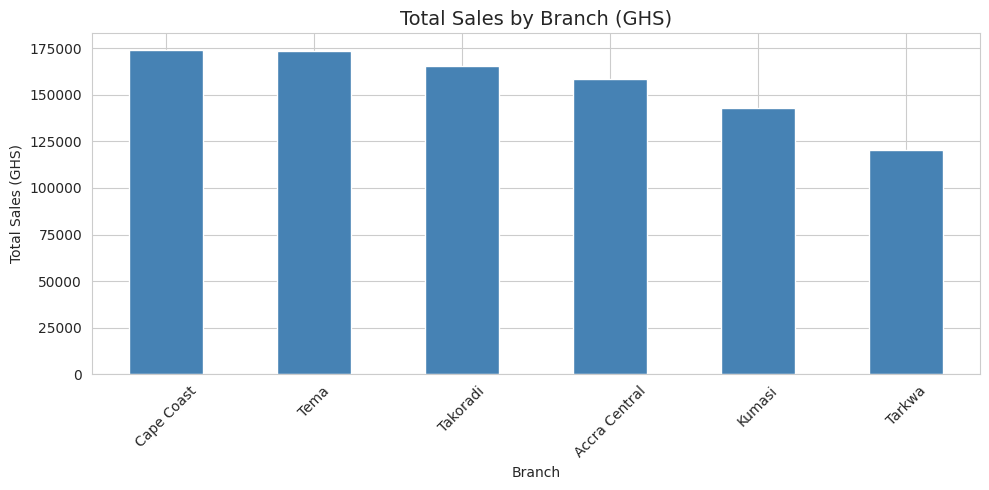

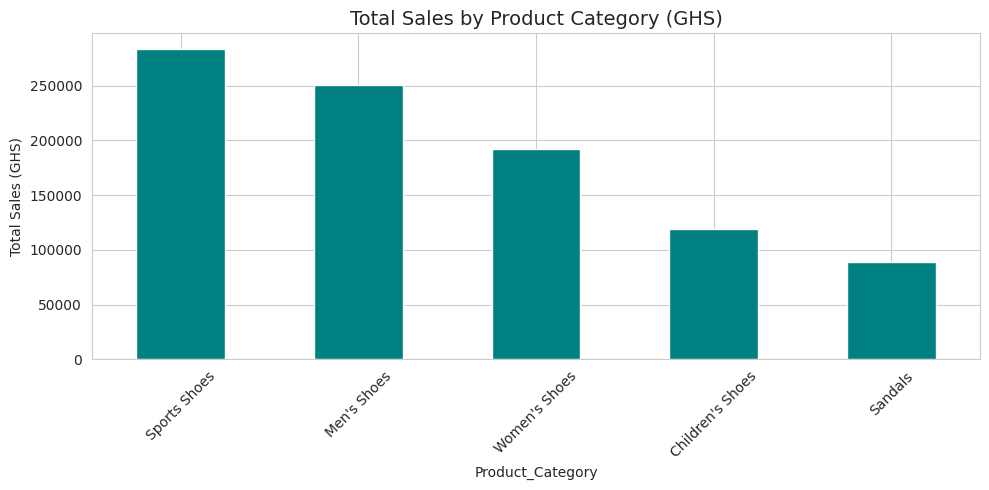

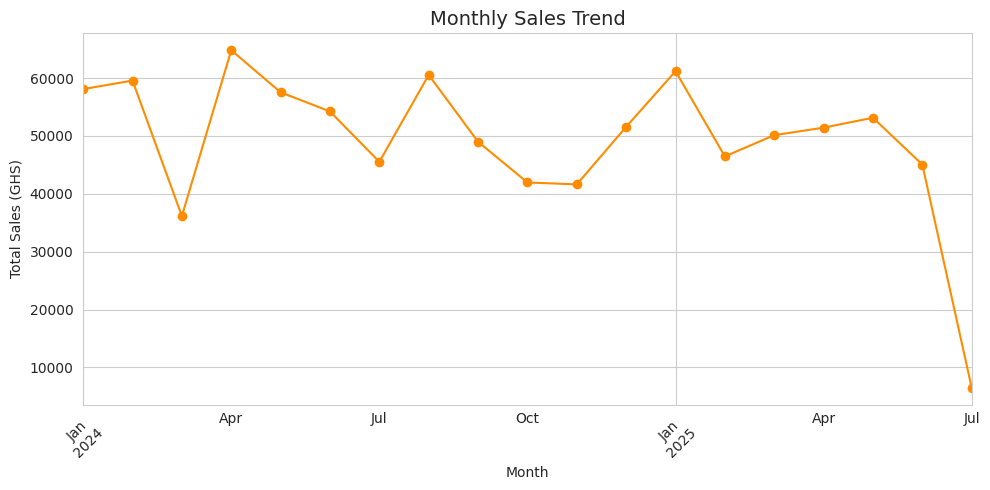

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# 1. Sales by Branch
plt.figure()
sales_by_branch.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Branch (GHS)', fontsize=14)
plt.ylabel('Total Sales (GHS)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Sales by Product Category
plt.figure()
sales_by_category.plot(kind='bar', color='teal')
plt.title('Total Sales by Product Category (GHS)', fontsize=14)
plt.ylabel('Total Sales (GHS)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Monthly Sales Trend
plt.figure()
monthly_sales.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Sales Trend', fontsize=14)
plt.ylabel('Total Sales (GHS)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
print("""
KEY INSIGHTS
------------
1. Top performing branches: Cape Coast and Tema generated the highest total sales.
2. Greater Accra is the strongest region overall.
3. Sports Shoes is the highest revenue product category.
4. Monthly sales were mixed, with a noticeable decline in July 2025.
5. Kumasi has the lowest average stock levels, indicating possible stock management issues.
6. Several low-stock situations (< 15 pairs) were identified, especially in certain categories and branches.

RECOMMENDATIONS
---------------
1. Investigate stock replenishment processes in Kumasi to avoid stockouts.
2. Increase focus on Sports Shoes (highest revenue category) across all branches.
3. Analyse the July 2025 sales drop to understand causes (seasonality, stock issues, or competition).
4. Consider redistributing slow-moving stock from high-stock branches to low-stock ones.
5. Introduce simple reorder alerts when stock falls below 15 pairs.
""")


KEY INSIGHTS
------------
1. Top performing branches: Cape Coast and Tema generated the highest total sales.
2. Greater Accra is the strongest region overall.
3. Sports Shoes is the highest revenue product category.
4. Monthly sales were mixed, with a noticeable decline in July 2025.
5. Kumasi has the lowest average stock levels, indicating possible stock management issues.
6. Several low-stock situations (< 15 pairs) were identified, especially in certain categories and branches.

RECOMMENDATIONS
---------------
1. Investigate stock replenishment processes in Kumasi to avoid stockouts.
2. Increase focus on Sports Shoes (highest revenue category) across all branches.
3. Analyse the July 2025 sales drop to understand causes (seasonality, stock issues, or competition).
4. Consider redistributing slow-moving stock from high-stock branches to low-stock ones.
5. Introduce simple reorder alerts when stock falls below 15 pairs.

